In [142]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader , Dataset
from torchsummary import summary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [143]:
#Load and show dataset head
rice_data = pd.read_csv('riceClassification.csv')
rice_data.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [144]:
#describe dataset
rice_data.dtypes

id                   int64
Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Perimeter          float64
Roundness          float64
AspectRation       float64
Class                int64
dtype: object

In [145]:
#check for missing values
rice_data.isna().sum()

id                 0
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

In [146]:
#drop id column
rice_data.drop(inplace=True , columns=['id'])
rice_data.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [147]:
#Show the data shape
rice_data.shape

(18185, 11)

In [148]:
#Show all unique classes
rice_data['Class'].unique()

array([1, 0])

In [149]:
#Show ratio of each class
rice_data['Class'].value_counts().map(lambda count : round(count / len(rice_data) * 100 , 2))

Class
1    54.91
0    45.09
Name: count, dtype: float64

In [150]:
#split data into train and test set
X = rice_data.drop(columns=['Class'])
y = rice_data['Class']

X_train, X_ , y_train , y_ = train_test_split(X , y , test_size=0.3 , random_state=42)

X_val , X_test , y_val , y_test = train_test_split(X_ , y_ , test_size=0.5 , random_state=42)

In [151]:
X_train.shape , X_val.shape , X_test.shape

((12729, 10), (2728, 10), (2728, 10))

In [152]:
#Scale numeric features for training set
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.dtype

dtype('float64')

In [153]:
class RiceDataset(Dataset):
    def __init__(self , features , targets):
        super(RiceDataset , self).__init__()
        self.features = torch.tensor(np.array(features) , dtype=torch.float32)
        self.targets = torch.tensor(np.array(targets) , dtype=torch.float32)

    def __len__(self):
        return len(self.features)

    def __getitem__(self , idx):
        return {'X' : self.features[idx] , 'y' : self.targets[idx]}

In [154]:
#Put each split in a dataset class
training_dataset = RiceDataset(X_train , y_train)
validation_dataset = RiceDataset(X_val , y_val)
test_dataset = RiceDataset(X_test , y_test)

len(training_dataset)

12729

In [155]:
#Create a data loader for each split (train , cv , test)
training_data_loader = DataLoader(training_dataset , batch_size=32 , shuffle=True)
validation_data_loader = DataLoader(val_dataset , batch_size=32 , shuffle=True)
test_data_loader = DataLoader(test_dataset , batch_size=32 , shuffle=True)

In [156]:
#Create the classification model
class BCModel(nn.Module):
    def __init__(self , in_features , hidden_features , out_features):
        super(BCModel , self).__init__()
        self.linear1 = nn.Linear(in_features , hidden_features)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_features , out_features)

    def forward(self , x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x

In [157]:
#Build the model and define loss function and optimizer
in_features = 10
hidden_features = 10
out_features = 1

model = BCModel(in_features , hidden_features , out_features)

summary(model , (in_features,))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 10]                  110
├─ReLU: 1-2                              [-1, 10]                  --
├─Linear: 1-3                            [-1, 1]                   11
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00


Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 10]                  110
├─ReLU: 1-2                              [-1, 10]                  --
├─Linear: 1-3                            [-1, 1]                   11
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [158]:
criterion = nn.BCEWithLogitsLoss()

optimizer = Adam(model.parameters() , lr=0.01)

In [159]:
#Train the model on training and cross-validation data
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

epochs = 20

for epoch in range(epochs):
    total_loss_train = 0.0
    correct_train = 0
    total_loss_val = 0.0
    correct_val = 0
    
    # --- Training Loop ---
    model.train()
    for data in training_data_loader:
        features = data['X']
        targets = data['y']
        
        optimizer.zero_grad()
        predictions = model(features).squeeze(1)
        loss = criterion(predictions, targets)
        
        loss.backward()
        optimizer.step()
        
        total_loss_train += loss.item()
        correct_train += ((predictions > 0) == targets).sum().item()
        
    # --- Validation Loop ---
    model.eval()
    with torch.no_grad():
        for data in validation_data_loader:
            features = data['X']
            targets = data['y']
            
            predictions = model(features).squeeze(1)
            loss = criterion(predictions, targets)
            
            total_loss_val += loss.item()
            correct_val += ((predictions > 0) == targets).sum().item()
            
    # Calculate Epoch Averages
    epoch_loss_train = round(total_loss_train / len(training_data_loader), 4)
    epoch_acc_train = (correct_train / len(training_dataset)) * 100
    
    epoch_loss_val = round(total_loss_val / len(validation_data_loader), 4)
    epoch_acc_val = (correct_val / len(validation_dataset)) * 100
    
    total_loss_train_plot.append(epoch_loss_train)
    total_loss_validation_plot.append(epoch_loss_val)
    total_acc_train_plot.append(epoch_acc_train)
    total_acc_validation_plot.append(epoch_acc_val)
    
    print(f"Epoch {epoch + 1}:")
    print(f"  Training Loss: {epoch_loss_train}, Training Accuracy: {epoch_acc_train:.2f}%")
    print(f"  Validation Loss: {epoch_loss_val}, Validation Accuracy: {epoch_acc_val:.2f}%")
    print('=' * 100)
        

Epoch 1:
  Training Loss: 0.0705, Training Accuracy: 97.86%
  Validation Loss: 0.026, Validation Accuracy: 99.01%
Epoch 2:
  Training Loss: 0.0368, Training Accuracy: 98.81%
  Validation Loss: 0.0227, Validation Accuracy: 99.38%
Epoch 3:
  Training Loss: 0.0357, Training Accuracy: 98.91%
  Validation Loss: 0.0226, Validation Accuracy: 99.38%
Epoch 4:
  Training Loss: 0.0343, Training Accuracy: 98.88%
  Validation Loss: 0.0221, Validation Accuracy: 99.34%
Epoch 5:
  Training Loss: 0.0342, Training Accuracy: 98.94%
  Validation Loss: 0.0223, Validation Accuracy: 99.34%
Epoch 6:
  Training Loss: 0.0333, Training Accuracy: 98.88%
  Validation Loss: 0.0217, Validation Accuracy: 99.38%
Epoch 7:
  Training Loss: 0.0343, Training Accuracy: 98.88%
  Validation Loss: 0.0227, Validation Accuracy: 99.27%
Epoch 8:
  Training Loss: 0.0335, Training Accuracy: 98.92%
  Validation Loss: 0.0234, Validation Accuracy: 99.41%
Epoch 9:
  Training Loss: 0.0326, Training Accuracy: 98.95%
  Validation Loss: 0.

In [176]:
# --- Test Loop ---
with torch.no_grad():

    total_loss_test = 0.0
    total_accuracy_test = 0.0
    
    for data in test_data_loader:
        features = data['X']
        targets = data['y']
            
        predictions = model(features).squeeze(1)
        loss = criterion(predictions, targets)
            
        total_loss_test += loss.item()
        total_accuracy_test += ((predictions > 0) == targets).sum().item()


    epoch_loss_test = round(total_loss_test / len(test_data_loader), 4)
    epoch_acc_test = (total_accuracy_test / len(test_dataset)) * 100


    print(f"Test Loss: {epoch_loss_test}, Test Accuracy: {epoch_acc_test:.2f}%")

Test Loss: 0.0349, Test Accuracy: 98.72%


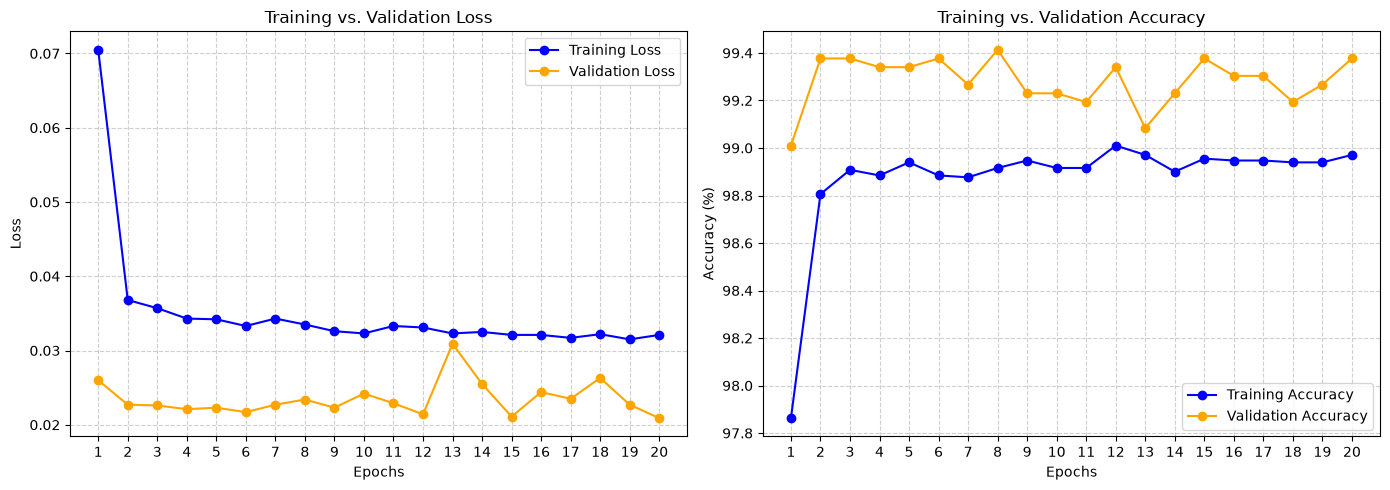

In [177]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, total_loss_train_plot, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, total_loss_validation_plot, label='Validation Loss', color='orange', marker='o')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, total_acc_train_plot, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, total_acc_validation_plot, label='Validation Accuracy', color='orange', marker='o')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [181]:
#INFERENCE

# 1. Set the model to evaluation mode
model.eval()

# Example: A new raw feature vector (10 features)
# Note: Raw features must be scaled using the fitted scaler before passing to the model
sample_raw_features = [[4537, 92.22, 64.01, 0.719, 4677, 76.00, 0.657, 273.08, 0.764, 1.44]]

# 2. Preprocess: Scale features using your fitted StandardScaler
scaled_features = scaler.transform(sample_raw_features)

# 3. Convert to a PyTorch FloatTensor
input_tensor = torch.tensor(scaled_features, dtype=torch.float32)

# 4. Perform inference without computing gradients
with torch.no_grad():
    logit = model(input_tensor).squeeze()
    probability = torch.sigmoid(logit).item()
    predicted_class = int(logit > 0)  # 1 if probability > 0.5, else 0

print(f"Logit: {logit.item():.4f}")
print(f"Predicted Probability of Class 1: {probability * 100:.2f}%")
print(f"Predicted Class: {predicted_class}")

Logit: 9.0602
Predicted Probability of Class 1: 99.99%
Predicted Class: 1


C:\Users\rasha\miniconda3\envs\AI-ML-3.12\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
